# Prior-knowledge alignment (GO ↔ Cell Painting compartments)

Implements **section G** from the joint-space alternatives plan: soft biological
correspondence between modalities via matched compartment blocks — not
gene↔feature identity.

Pipeline:

1. Load compound-level morphology consensus (`morphology_all_sites_consensus.h5ad`),
   cell-level expression (`expression_hepg2.h5ad`), and the global EVPC joint
   embedding for comparison.
2. Define **morphology blocks** from Cell Painting channel / object structure
   (DNA, Mito, ER, AGP, cell-shape).
3. Fetch **GO Cellular Component** gene sets (QuickGO, cached) for matched
   compartments (nucleus, mitochondrion, ER, actin cytoskeleton + Golgi,
   plasma membrane).
4. Pseudobulk expression per compound and score each GO block.
5. **Block Mantel** concordance (matched pairs + full morph×RNA heatmap).
6. Per-block PCA → **prior-guided joint space** (equal-variance across blocks)
   and a **concordance-weighted** variant; compare MoA silhouette / UMAP to
   global EVPC.

SNF fusion (section G+C) is left for a follow-up notebook.

In [1]:
import json
import warnings
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import scanpy as sc
from scipy import sparse
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from sklearn.cross_decomposition import CCA
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sc.settings.verbosity = 0
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"
plt.rcParams["font.size"] = 10

RANDOM_STATE = 0
N_BLOCK_PCS = 5
N_MANTEL_PERM = 999
MIN_GENES_IN_SET = 10
MIN_FEATURES_IN_BLOCK = 5

DATA_DIR = Path("./data")
EMBEDDING_DIR = DATA_DIR / "compound_embeddings"
PRIOR_DIR = DATA_DIR / "prior_knowledge"
PRIOR_DIR.mkdir(parents=True, exist_ok=True)

MORPH_H5AD = DATA_DIR / "morphology_all_sites_consensus.h5ad"
EXPR_H5AD = DATA_DIR / "expression_hepg2.h5ad"
EVPC_H5AD = EMBEDDING_DIR / "joint_evpc.h5ad"
MORPH_EMB_H5AD = EMBEDDING_DIR / "morphology.h5ad"
EXPR_EMB_H5AD = EMBEDDING_DIR / "expression.h5ad"

PALETTE = [
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4",
    "#008300", "#4a3aa7", "#e34948", "#6b4226", "#38a5b0",
    "#a24fbf", "#c2914e", "#5a6bd6", "#c65da0", "#6f9e1f",
    "#d65f5f", "#3f7d8c", "#9a7dcb", "#b25b2a", "#4f9d6e",
    "#8c8c8c",
]

## 1. Load compound-level morphology and expression

Morphology consensus is already one row per shared drug. Expression is
cell-level (log-normalised UMI-scale matrix); we pseudobulk to compound means
after restricting to the shared compound set.

In [2]:
morph = ad.read_h5ad(MORPH_H5AD)
expr_cells = ad.read_h5ad(EXPR_H5AD)
evpc = ad.read_h5ad(EVPC_H5AD)
emb_morph = ad.read_h5ad(MORPH_EMB_H5AD)
emb_expr = ad.read_h5ad(EXPR_EMB_H5AD)

shared_compounds = [d for d in morph.obs_names.tolist() if d in set(evpc.obs_names)]
morph = morph[shared_compounds].copy()
evpc = evpc[shared_compounds].copy()
emb_morph = emb_morph[shared_compounds].copy()
emb_expr = emb_expr[shared_compounds].copy()

moa_shared = morph.obs["Metadata_moa_fine"].astype(str)

expr_cells = expr_cells[expr_cells.obs["Metadata_Drug"].isin(shared_compounds)].copy()
expr_cells.var_names = expr_cells.var["gene_symbol"].astype(str).to_numpy()
expr_cells.var_names_make_unique()

# Pseudobulk: mean log-expression per drug (compounds x genes)
drugs = expr_cells.obs["Metadata_Drug"].astype(str).to_numpy()
X = expr_cells.X.tocsr() if sparse.issparse(expr_cells.X) else np.asarray(expr_cells.X)
rows = []
for drug in shared_compounds:
    idx = np.where(drugs == drug)[0]
    if len(idx) == 0:
        raise ValueError(f"No expression cells for drug {drug!r}")
    rows.append(np.asarray(X[idx].mean(axis=0)).ravel().astype(np.float32))

expr_pb = ad.AnnData(
    X=np.vstack(rows),
    obs=pd.DataFrame(index=pd.Index(shared_compounds, name="Metadata_Drug")),
    var=expr_cells.var.copy(),
)

print(f"Morphology consensus: {morph.shape}")
print(f"Expression pseudobulk: {expr_pb.shape}")
print(f"Shared compounds: {len(shared_compounds)}")
print(moa_shared.value_counts().head())

Morphology consensus: (119, 636)
Expression pseudobulk: (119, 62710)
Shared compounds: 119
Metadata_moa_fine
unclear                           55
DNA synthesis/repair inhibitor    14
MTOR inhibitor                     5
Other MAPK inhibitor               4
CDK inhibitor                      3
Name: count, dtype: int64


## 2. Define matched compartment blocks

Each block pairs a Cell Painting feature group with one or more GO Cellular
Component terms. Morphology uses channel tags in feature names (`DNA`, `Mito`,
`ER`, `AGP`); nuclear/cell AreaShape features without a channel tag are used as
shape proxies. This dataset has no separate RNA/nucleoli channel after feature
selection.

Gene sets are pulled from [QuickGO](https://www.ebi.ac.uk/QuickGO/) (human
protein annotations, GO descendants) and cached under `data/prior_knowledge/`.

In [3]:
# Matched prior blocks: morph feature rule + GO term(s) to union.
MATCHED_BLOCKS = {
    "nucleus": {
        "description": "DNA channel + nuclear shape ↔ nucleus",
        "go_ids": ["GO:0005634"],  # nucleus
        "morph": {"channels": ["DNA"], "shape_compartments": ["Nuc"]},
    },
    "mitochondrion": {
        "description": "Mito channel ↔ mitochondrion",
        "go_ids": ["GO:0005739"],
        "morph": {"channels": ["Mito"], "shape_compartments": []},
    },
    "endoplasmic_reticulum": {
        "description": "ER channel ↔ endoplasmic reticulum",
        "go_ids": ["GO:0005783"],
        "morph": {"channels": ["ER"], "shape_compartments": []},
    },
    "cytoskeleton_agp": {
        "description": "AGP channel ↔ actin cytoskeleton + Golgi",
        "go_ids": ["GO:0015629", "GO:0005794"],  # actin cytoskeleton, Golgi apparatus
        "morph": {"channels": ["AGP"], "shape_compartments": []},
    },
    "plasma_membrane": {
        "description": "Cell/cyto shape ↔ plasma membrane (soft proxy)",
        "go_ids": ["GO:0005886"],
        "morph": {"channels": [], "shape_compartments": ["Cells", "Cyto"]},
    },
}


def morph_features_for_block(var_names: pd.Index, rule: dict) -> list[str]:
    """Select CP features by channel token and/or shape features on compartments."""
    selected: list[str] = []
    channels = set(rule.get("channels", []))
    shape_comps = set(rule.get("shape_compartments", []))
    for name in var_names:
        parts = name.split("_")
        compartment = parts[0] if parts else ""
        channel_hit = any(p in channels for p in parts)
        is_shape = "AreaShape" in name or "Neighbors" in name
        has_channel = any(p in {"DNA", "RNA", "AGP", "Mito", "ER"} for p in parts)
        if channel_hit:
            selected.append(name)
        elif is_shape and not has_channel and compartment in shape_comps:
            selected.append(name)
    return selected


morph_block_features: dict[str, list[str]] = {}
for block, spec in MATCHED_BLOCKS.items():
    feats = morph_features_for_block(morph.var_names, spec["morph"])
    morph_block_features[block] = feats
    print(f"{block:24s}  morph features={len(feats):4d}  GO={', '.join(spec['go_ids'])}")

covered = sorted({f for feats in morph_block_features.values() for f in feats})
print(f"\nUnique morph features in any block: {len(covered)} / {morph.n_vars}")

nucleus                   morph features= 220  GO=GO:0005634
mitochondrion             morph features= 110  GO=GO:0005739
endoplasmic_reticulum     morph features= 145  GO=GO:0005783
cytoskeleton_agp          morph features= 133  GO=GO:0015629, GO:0005794
plasma_membrane           morph features=  72  GO=GO:0005886

Unique morph features in any block: 599 / 636


In [4]:
def fetch_quickgo_symbols(go_id: str, cache_path: Path) -> set[str]:
    """Human gene symbols annotated to go_id or descendants (QuickGO TSV)."""
    if cache_path.exists():
        return set(json.loads(cache_path.read_text(encoding="utf-8")))

    url = "https://www.ebi.ac.uk/QuickGO/services/annotation/downloadSearch"
    params = {
        "geneProductType": "protein",
        "goId": go_id,
        "taxonId": 9606,
        "goUsage": "descendants",
        "goUsageRelationships": "is_a,part_of,occurs_in",
        "selectedFields": "geneProductId,symbol,goId",
    }
    resp = requests.get(url, params=params, headers={"Accept": "text/tsv"}, timeout=180)
    resp.raise_for_status()
    lines = resp.text.splitlines()
    symbols: set[str] = set()
    for line in lines[1:]:  # skip header
        parts = line.split("\t")
        if len(parts) < 3:
            continue
        symbol = parts[2].strip()
        if symbol and symbol != "-":
            symbols.add(symbol)
    cache_path.write_text(json.dumps(sorted(symbols)), encoding="utf-8")
    return symbols


go_block_genes: dict[str, list[str]] = {}
expr_genes = set(expr_pb.var_names.astype(str))

for block, spec in MATCHED_BLOCKS.items():
    union: set[str] = set()
    for go_id in spec["go_ids"]:
        cache = PRIOR_DIR / f"{go_id.replace(':', '_')}_symbols.json"
        symbols = fetch_quickgo_symbols(go_id, cache)
        union |= symbols
        print(f"  {go_id}: {len(symbols)} symbols (cached={cache.name})")
    present = sorted(g for g in union if g in expr_genes)
    go_block_genes[block] = present
    print(f"{block:24s}  GO genes in matrix={len(present):4d} / {len(union)} annotated\n")

  GO:0005634: 2261 symbols (cached=GO_0005634_symbols.json)
nucleus                   GO genes in matrix=2002 / 2261 annotated

  GO:0005739: 1635 symbols (cached=GO_0005739_symbols.json)
mitochondrion             GO genes in matrix= 921 / 1635 annotated

  GO:0005783: 1805 symbols (cached=GO_0005783_symbols.json)
endoplasmic_reticulum     GO genes in matrix= 991 / 1805 annotated

  GO:0015629: 971 symbols (cached=GO_0015629_symbols.json)
  GO:0005794: 1722 symbols (cached=GO_0005794_symbols.json)
cytoskeleton_agp          GO genes in matrix=1692 / 2642 annotated

  GO:0005886: 7065 symbols (cached=GO_0005886_symbols.json)
plasma_membrane           GO genes in matrix= 966 / 7065 annotated



## 3. Block embeddings

- **Morphology**: z-score features within each block, then PCA (`N_BLOCK_PCS`).
- **Expression**: z-score genes across compounds, then mean of genes in the GO
  set (pathway score) plus PCA on the GO gene subset (same `N_BLOCK_PCS`) so
  both sides contribute multi-dimensional block spaces for Mantel / joint
  concat. The 1-D mean score is kept for a simple diagnostic.

In [5]:
def zscore_df(df: pd.DataFrame, axis: int = 0) -> pd.DataFrame:
    """Z-score columns (axis=0) or rows (axis=1)."""
    if axis == 0:
        std = df.std(axis=0, ddof=0).replace(0, 1)
        return (df - df.mean(axis=0)) / std
    std = df.std(axis=1, ddof=0).replace(0, 1)
    return df.sub(df.mean(axis=1), axis=0).div(std, axis=0)


def block_pca(X: np.ndarray, n_pcs: int, random_state: int = 0) -> np.ndarray:
    n_pcs = int(min(n_pcs, X.shape[0] - 1, X.shape[1]))
    if n_pcs < 1:
        raise ValueError("Block too small for PCA")
    pcs = PCA(n_components=n_pcs, random_state=random_state).fit_transform(X)
    return pcs


morph_X = pd.DataFrame(
    morph.X if not hasattr(morph.X, "toarray") else morph.X.toarray(),
    index=morph.obs_names,
    columns=morph.var_names,
).astype(np.float64)

expr_X = pd.DataFrame(
    expr_pb.X if not hasattr(expr_pb.X, "toarray") else np.asarray(expr_pb.X),
    index=expr_pb.obs_names,
    columns=expr_pb.var_names.astype(str),
).astype(np.float64)

morph_block_pcs: dict[str, pd.DataFrame] = {}
rna_block_pcs: dict[str, pd.DataFrame] = {}
rna_block_mean_score: dict[str, pd.Series] = {}
block_summary_rows = []

for block, spec in MATCHED_BLOCKS.items():
    m_feats = morph_block_features[block]
    g_genes = go_block_genes[block]
    if len(m_feats) < MIN_FEATURES_IN_BLOCK:
        print(f"SKIP {block}: only {len(m_feats)} morph features")
        continue
    if len(g_genes) < MIN_GENES_IN_SET:
        print(f"SKIP {block}: only {len(g_genes)} GO genes in matrix")
        continue

    m_z = zscore_df(morph_X[m_feats], axis=0)
    m_pcs = block_pca(m_z.to_numpy(), N_BLOCK_PCS, RANDOM_STATE)
    morph_block_pcs[block] = pd.DataFrame(
        m_pcs,
        index=shared_compounds,
        columns=[f"{block}_morph_PC{i}" for i in range(m_pcs.shape[1])],
    )

    g_z = zscore_df(expr_X[g_genes], axis=0)
    rna_block_mean_score[block] = g_z.mean(axis=1).rename(f"{block}_rna_mean")
    r_pcs = block_pca(g_z.to_numpy(), N_BLOCK_PCS, RANDOM_STATE)
    rna_block_pcs[block] = pd.DataFrame(
        r_pcs,
        index=shared_compounds,
        columns=[f"{block}_rna_PC{i}" for i in range(r_pcs.shape[1])],
    )

    block_summary_rows.append(
        {
            "block": block,
            "n_morph_features": len(m_feats),
            "n_go_genes": len(g_genes),
            "n_morph_pcs": m_pcs.shape[1],
            "n_rna_pcs": r_pcs.shape[1],
        }
    )

block_summary = pd.DataFrame(block_summary_rows).set_index("block")
active_blocks = list(morph_block_pcs.keys())
print(f"Active blocks: {active_blocks}")
block_summary

Active blocks: ['nucleus', 'mitochondrion', 'endoplasmic_reticulum', 'cytoskeleton_agp', 'plasma_membrane']


,n_morph_features,n_go_genes,n_morph_pcs,n_rna_pcs
block,,,,
nucleus,220,2002,5,5
mitochondrion,110,921,5,5
endoplasmic_reticulum,145,991,5,5
cytoskeleton_agp,133,1692,5,5
plasma_membrane,72,966,5,5


## 4. Block Mantel concordance

For each morph block and each RNA block, Spearman-correlate the upper triangles
of compound–compound Euclidean distance matrices (Mantel-style), with a
permutation null on the matched diagonal. High on-diagonal values mean the
prior-matched compartments agree on which compounds look alike.

In [6]:
def mantel_spearman(X: np.ndarray, Y: np.ndarray, n_perm: int = 999, seed: int = 0):
    """Spearman Mantel between two sample x feature matrices."""
    dx = squareform(pdist(X))
    dy = squareform(pdist(Y))
    iu = np.triu_indices(X.shape[0], k=1)
    r, _ = spearmanr(dx[iu], dy[iu])
    rng = np.random.RandomState(seed)
    null = np.empty(n_perm)
    idx = np.arange(X.shape[0])
    for i in range(n_perm):
        perm = rng.permutation(idx)
        null[i], _ = spearmanr(dx[iu], dy[np.ix_(perm, perm)][iu])
    p = (np.sum(np.abs(null) >= abs(r)) + 1) / (n_perm + 1)
    return float(r), float(p)


mantel_r = pd.DataFrame(index=active_blocks, columns=active_blocks, dtype=float)
mantel_p = pd.DataFrame(index=active_blocks, columns=active_blocks, dtype=float)

iu = np.triu_indices(len(shared_compounds), k=1)
for m_block in active_blocks:
    Xm = morph_block_pcs[m_block].to_numpy()
    dx = squareform(pdist(Xm))
    for r_block in active_blocks:
        Xr = rna_block_pcs[r_block].to_numpy()
        if m_block == r_block:
            # Full permutation test only on matched (diagonal) pairs
            r, p = mantel_spearman(Xm, Xr, n_perm=N_MANTEL_PERM, seed=RANDOM_STATE)
        else:
            dy = squareform(pdist(Xr))
            r = float(spearmanr(dx[iu], dy[iu])[0])
            p = np.nan
        mantel_r.loc[m_block, r_block] = r
        mantel_p.loc[m_block, r_block] = p

matched = pd.DataFrame(
    {
        "mantel_r": [mantel_r.loc[b, b] for b in active_blocks],
        "mantel_p": [mantel_p.loc[b, b] for b in active_blocks],
        "n_morph_features": block_summary.loc[active_blocks, "n_morph_features"].to_numpy(),
        "n_go_genes": block_summary.loc[active_blocks, "n_go_genes"].to_numpy(),
    },
    index=active_blocks,
)
print("Matched-block Mantel (morph ↔ RNA within compartment):")
matched.sort_values("mantel_r", ascending=False)

Matched-block Mantel (morph ↔ RNA within compartment):


,mantel_r,mantel_p,n_morph_features,n_go_genes
endoplasmic_reticulum,0.210900,0.001,145,991
cytoskeleton_agp,0.178140,0.001,133,1692
mitochondrion,0.165192,0.001,110,921
plasma_membrane,0.160584,0.003,72,966
nucleus,0.159757,0.002,220,2002


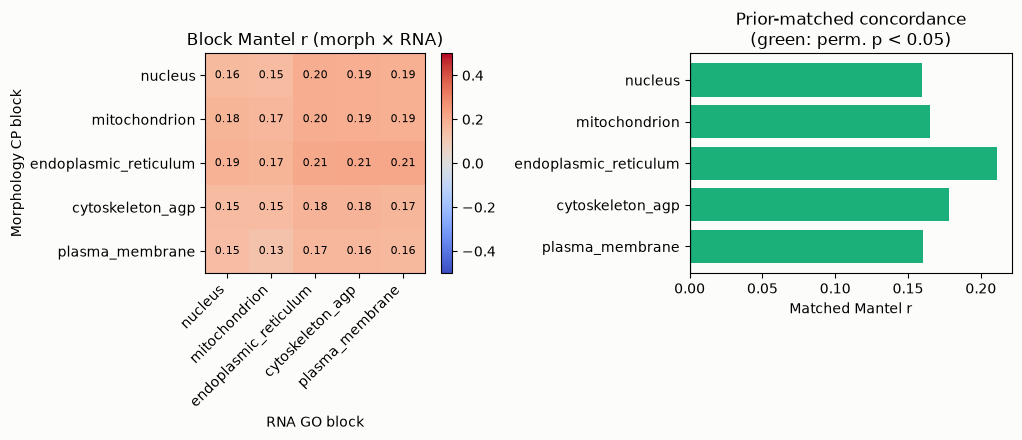

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

im0 = axes[0].imshow(mantel_r.to_numpy(dtype=float), cmap="coolwarm", vmin=-0.5, vmax=0.5)
axes[0].set_xticks(range(len(active_blocks)))
axes[0].set_yticks(range(len(active_blocks)))
axes[0].set_xticklabels(active_blocks, rotation=45, ha="right")
axes[0].set_yticklabels(active_blocks)
axes[0].set_xlabel("RNA GO block")
axes[0].set_ylabel("Morphology CP block")
axes[0].set_title("Block Mantel r (morph × RNA)")
for i in range(len(active_blocks)):
    for j in range(len(active_blocks)):
        axes[0].text(j, i, f"{mantel_r.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im0, ax=axes[0], fraction=0.046)

colors = ["#1baf7a" if p < 0.05 else "#8c8c8c" for p in matched["mantel_p"]]
axes[1].barh(matched.index, matched["mantel_r"], color=colors)
axes[1].axvline(0, color="k", lw=0.8)
axes[1].set_xlabel("Matched Mantel r")
axes[1].set_title("Prior-matched concordance\n(green: perm. p < 0.05)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Blockwise CCA (optional shared axes)

Within each matched compartment, fit CCA between morph block PCs and RNA block
PCs. Report the first canonical correlation as another concordance summary;
average the first canonical variates across blocks for a compact shared
embedding (blocks with non-positive Mantel r are downweighted).

In [8]:
cca_rows = []
cca_variates = []
cca_weights = []

for block in active_blocks:
    Xm = StandardScaler().fit_transform(morph_block_pcs[block].to_numpy())
    Xr = StandardScaler().fit_transform(rna_block_pcs[block].to_numpy())
    n_comp = int(min(2, Xm.shape[1], Xr.shape[1], Xm.shape[0] // 10))
    n_comp = max(n_comp, 1)
    cca = CCA(n_components=n_comp, max_iter=500)
    Um, Ur = cca.fit_transform(Xm, Xr)
    corr = float(np.corrcoef(Um[:, 0], Ur[:, 0])[0, 1])
    w = max(float(matched.loc[block, "mantel_r"]), 0.0)
    cca_rows.append({"block": block, "cca_r1": corr, "n_components": n_comp, "mantel_weight": w})
    # Shared direction: average of the two views' first variate
    shared = 0.5 * (Um[:, 0] + Ur[:, 0])
    cca_variates.append(shared)
    cca_weights.append(w)

cca_summary = pd.DataFrame(cca_rows).set_index("block")
print(cca_summary)

W = np.array(cca_weights, dtype=float)
if W.sum() == 0:
    W = np.ones_like(W)
W = W / W.sum()
cca_joint = np.column_stack(cca_variates)  # compounds x blocks
cca_weighted_1d = cca_joint @ W
cca_joint_df = pd.DataFrame(
    cca_joint,
    index=shared_compounds,
    columns=[f"cca_{b}" for b in active_blocks],
)
cca_joint_df["cca_weighted"] = cca_weighted_1d
cca_joint_df.head()

                         cca_r1  n_components  mantel_weight
block                                                       
nucleus                0.724831             2       0.159757
mitochondrion          0.638914             2       0.165192
endoplasmic_reticulum  0.748844             2       0.210900
cytoskeleton_agp       0.712784             2       0.178140
plasma_membrane        0.731091             2       0.160584


,cca_nucleus,cca_mitochondrion,cca_endoplasmic_reticulum,cca_cytoskeleton_agp,cca_plasma_membrane,cca_weighted
18β-Glycyrrhetinic acid,-0.354764,0.115276,-0.191280,0.035362,-0.178857,-0.114795
5-Fluorouracil,0.163762,0.034596,-0.212871,0.397975,-0.175227,0.034005
8-Hydroxyquinoline,-0.342783,-0.167684,0.077013,-0.108840,-0.196035,-0.133881
AT7519,1.391779,-1.086185,0.887188,1.097020,-0.023476,0.482155
AZD-8055,0.324497,-0.429123,0.157460,-0.122675,-0.213285,-0.047957


## 6. Prior-guided joint spaces

Two concatenations of block PCs (morph + RNA for every active compartment):

1. **Prior EVPC**: z-score each block's PCs, then scale by `1/sqrt(n_features_in_block_space)`
   so each morph/RNA block contributes equally.
2. **Concordance-weighted**: same, but multiply each matched morph/RNA block pair
   by `sqrt(max(mantel_r, 0))` so weakly concordant compartments shrink.

Compare MoA silhouette to global morphology PCs, expression PCs, and global EVPC.

In [9]:
def evpc_concat(blocks: list[np.ndarray]) -> np.ndarray:
    parts = []
    for X in blocks:
        X = np.asarray(X, dtype=float)
        X = (X - X.mean(axis=0)) / np.where(X.std(axis=0, ddof=0) == 0, 1, X.std(axis=0, ddof=0))
        parts.append(X / np.sqrt(X.shape[1]))
    return np.concatenate(parts, axis=1)


morph_parts = [morph_block_pcs[b].to_numpy() for b in active_blocks]
rna_parts = [rna_block_pcs[b].to_numpy() for b in active_blocks]
prior_evpc = evpc_concat(morph_parts + rna_parts)

# Concordance-weighted: scale each matched pair by sqrt(max(r,0))
weighted_parts = []
for b in active_blocks:
    w = np.sqrt(max(float(matched.loc[b, "mantel_r"]), 0.0))
    # still include block with tiny floor so space does not drop dimensions entirely
    w = max(w, 0.05)
    for X in (morph_block_pcs[b].to_numpy(), rna_block_pcs[b].to_numpy()):
        X = (X - X.mean(axis=0)) / np.where(X.std(axis=0, ddof=0) == 0, 1, X.std(axis=0, ddof=0))
        weighted_parts.append((X / np.sqrt(X.shape[1])) * w)
prior_weighted = np.concatenate(weighted_parts, axis=1)

spaces = {
    "morphology_global": np.asarray(emb_morph.X, dtype=float),
    "expression_global": np.asarray(emb_expr.X, dtype=float),
    "joint_evpc_global": np.asarray(evpc.X, dtype=float),
    "prior_evpc": prior_evpc,
    "prior_concordance_weighted": prior_weighted,
    "cca_block_concat": cca_joint_df[[c for c in cca_joint_df.columns if c.startswith("cca_") and c != "cca_weighted"]].to_numpy(),
}

moa_group_size = moa_shared.value_counts()
moa_mask = moa_shared.isin(moa_group_size[moa_group_size >= 2].index).to_numpy()
print(f"{moa_mask.sum()}/{len(shared_compounds)} compounds in moa-fine classes with >=2 members")

silhouette_by_space = pd.Series(
    {
        name: silhouette_score(X[moa_mask], moa_shared.to_numpy()[moa_mask])
        for name, X in spaces.items()
    },
    name="silhouette_by_moa_fine",
).sort_values(ascending=False)

print("Space dimensionalities:", {k: v.shape[1] for k, v in spaces.items()})
silhouette_by_space

118/119 compounds in moa-fine classes with >=2 members
Space dimensionalities: {'morphology_global': 30, 'expression_global': 30, 'joint_evpc_global': 60, 'prior_evpc': 50, 'prior_concordance_weighted': 50, 'cca_block_concat': 5}


joint_evpc_global            -0.188330
prior_concordance_weighted   -0.230949
prior_evpc                   -0.231556
expression_global            -0.237036
morphology_global            -0.260460
cca_block_concat             -0.395113
Name: silhouette_by_moa_fine, dtype: float64

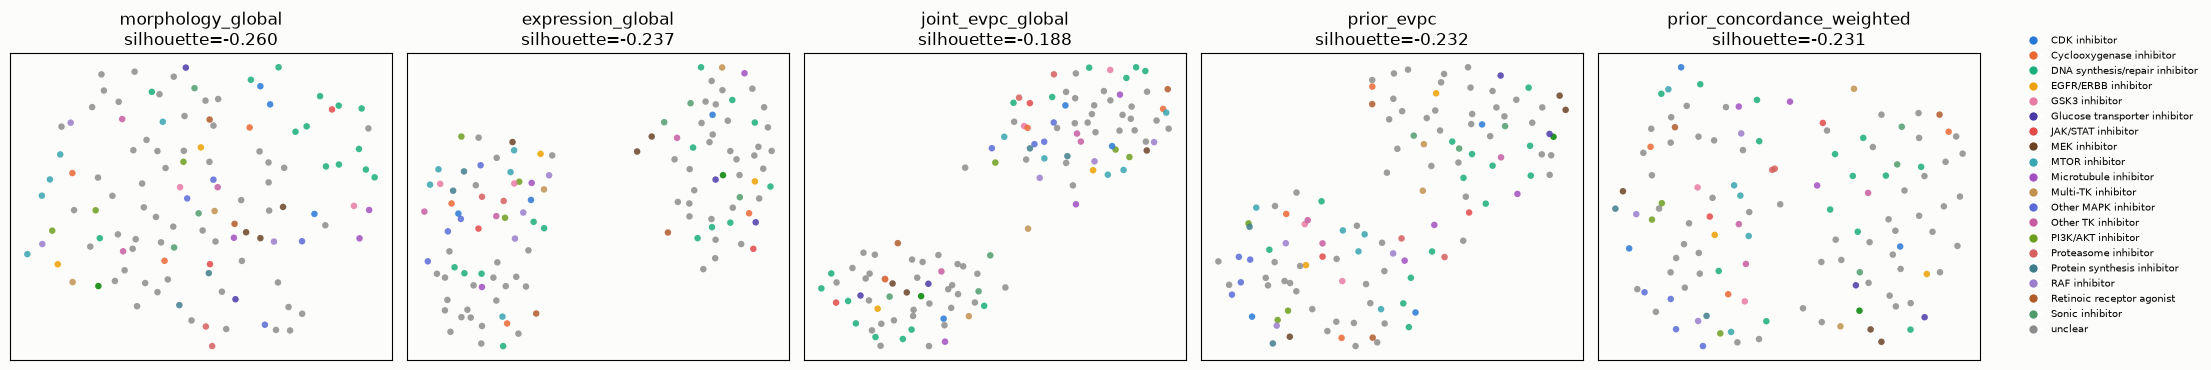

In [10]:
def embed_umap(X: np.ndarray) -> np.ndarray:
    tmp = ad.AnnData(X.astype(np.float32))
    n_neighbors = min(15, max(5, X.shape[0] // 4))
    sc.pp.neighbors(tmp, n_neighbors=n_neighbors, use_rep="X", random_state=RANDOM_STATE)
    sc.tl.umap(tmp, random_state=RANDOM_STATE)
    return tmp.obsm["X_umap"]


plot_spaces = [
    "morphology_global",
    "expression_global",
    "joint_evpc_global",
    "prior_evpc",
    "prior_concordance_weighted",
]

moa_levels = sorted(moa_shared.unique())
moa_to_color = {m: PALETTE[i % len(PALETTE)] for i, m in enumerate(moa_levels)}
colors = [moa_to_color[m] for m in moa_shared]

fig, axes = plt.subplots(1, len(plot_spaces), figsize=(4 * len(plot_spaces), 3.8))
for ax, name in zip(axes, plot_spaces):
    xy = embed_umap(spaces[name])
    ax.scatter(xy[:, 0], xy[:, 1], c=colors, s=22, alpha=0.85, linewidths=0)
    sil = silhouette_by_space[name]
    ax.set_title(f"{name}\nsilhouette={sil:.3f}")
    ax.set_xticks([])
    ax.set_yticks([])

handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=moa_to_color[m], markersize=7, label=m)
    for m in moa_levels
    if moa_group_size.get(m, 0) >= 2
]
fig.legend(handles=handles, loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=7, frameon=False)
plt.tight_layout()
plt.show()

## 7. Export prior-guided embeddings

Write `prior_evpc` and `prior_concordance_weighted` under
`data/compound_embeddings/` for reuse in downstream tasks.

In [11]:
emb_obs = pd.DataFrame(
    {
        "Metadata_Drug": shared_compounds,
        "Metadata_moa_fine": moa_shared.astype(str).to_numpy(),
    },
    index=shared_compounds,
)
if "Metadata_pdid" in evpc.obs.columns:
    emb_obs["Metadata_pdid"] = evpc.obs.loc[shared_compounds, "Metadata_pdid"].astype(str).to_numpy()

exports = {
    "joint_prior_evpc": (
        prior_evpc,
        "prior_evpc_equal_variance_per_block",
        [c for b in active_blocks for c in list(morph_block_pcs[b].columns) + list(rna_block_pcs[b].columns)],
    ),
    "joint_prior_concordance_weighted": (
        prior_weighted,
        "prior_evpc_scaled_by_sqrt_max_mantel_r",
        [c for b in active_blocks for c in list(morph_block_pcs[b].columns) + list(rna_block_pcs[b].columns)],
    ),
}

for name, (X, scaling, var_names) in exports.items():
    adata = ad.AnnData(
        X=np.asarray(X, dtype=np.float32),
        obs=emb_obs.copy(),
        var=pd.DataFrame(index=var_names),
    )
    adata.uns["space"] = name
    adata.uns["scaling"] = scaling
    adata.uns["active_blocks"] = active_blocks
    adata.uns["matched_mantel_r"] = matched["mantel_r"].to_dict()
    path = EMBEDDING_DIR / f"{name}.h5ad"
    adata.write_h5ad(path)
    print(f"{path}: {adata.n_obs} compounds x {adata.n_vars} features")

# Also cache Mantel tables for the report
matched.to_csv(PRIOR_DIR / "matched_block_mantel.csv")
mantel_r.to_csv(PRIOR_DIR / "block_mantel_r_matrix.csv")
block_summary.to_csv(PRIOR_DIR / "block_summary.csv")
print(f"Wrote Mantel / block tables to {PRIOR_DIR}")

data\compound_embeddings\joint_prior_evpc.h5ad: 119 compounds x 50 features
data\compound_embeddings\joint_prior_concordance_weighted.h5ad: 119 compounds x 50 features
Wrote Mantel / block tables to data\prior_knowledge


## Takeaways

- Block Mantel asks whether **matched biology** agrees across modalities; the
  heatmap off-diagonal shows whether concordance is compartment-specific or
  global (e.g. shared stress).
- Prior EVPC is an unsupervised joint space that respects compartment structure;
  concordance weighting shrinks blocks that do not cross-modally agree.
- MoA silhouette remaining negative would mean organelle priors alone do not
  recover `moa-fine` geometry — consistent with stress-dominated expression and
  soft morph↔RNA correspondence.
- Natural next step: **concordance-weighted SNF** (section G+C) using the same
  block affinity graphs.